Bắt đầu Grid Search cho các giá trị K: [1, 2, 3, 4, 5]

------------------------------------------------------------


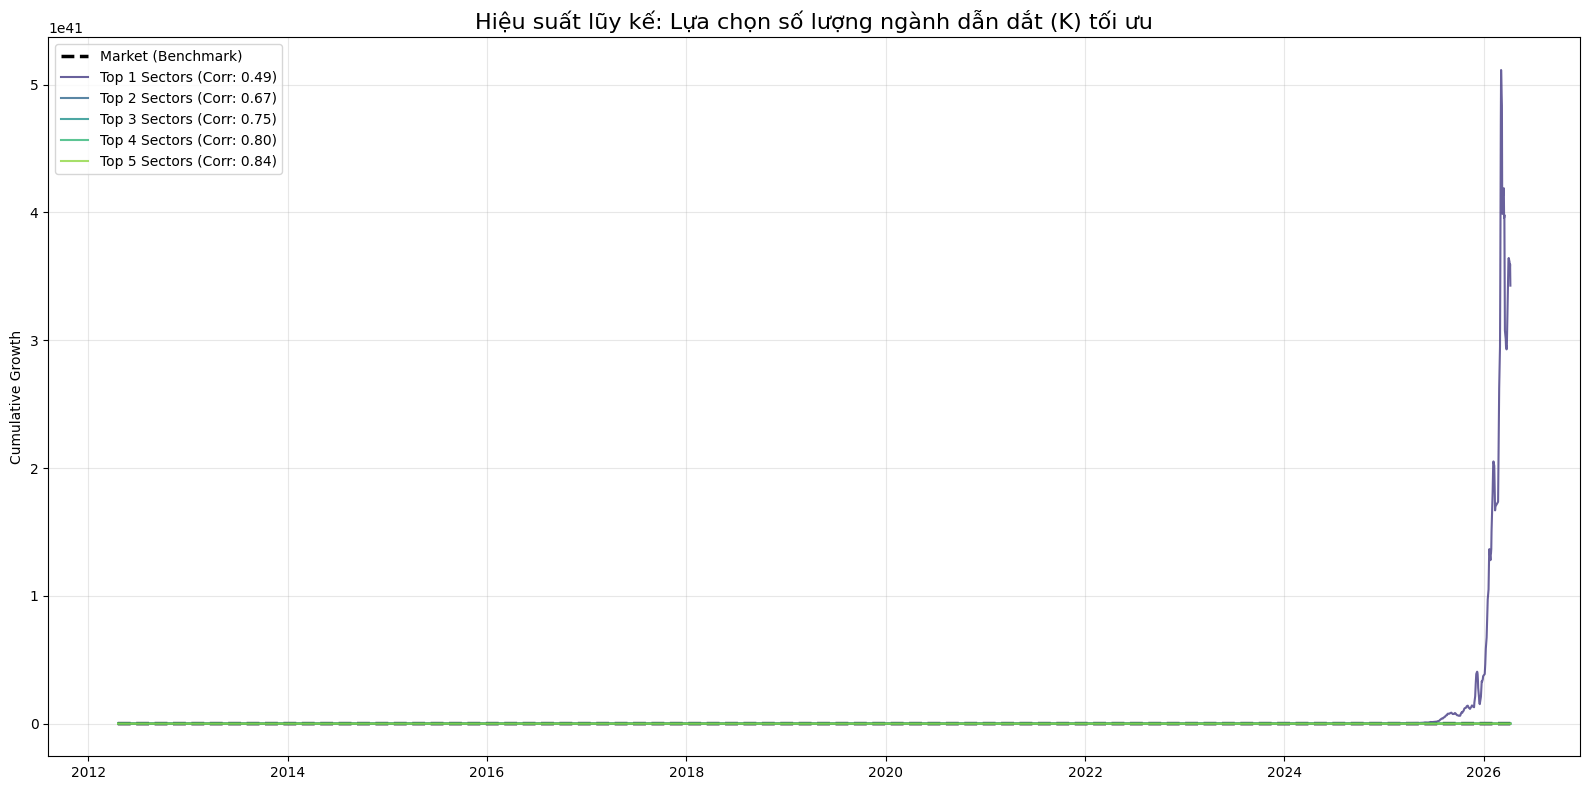


             BẢNG TỔNG HỢP KẾT QUẢ GRID SEARCH              


,K (Top Sectors),Correlation,Total Cumulative Return,Daily Volatility,Sharpe-like Ratio
0,1,0.4867,34274630226915169538006290817008371050217472.00%,0.0522,0.5575
1,2,0.6652,38339475990095528428148495154046566400.00%,0.0393,0.6234
2,3,0.7524,392591510770509015607499825348608.00%,0.0345,0.6083
3,4,0.8022,78905346284263527264276185088.00%,0.0321,0.5743
4,5,0.8366,133107950921963126332063744.00%,0.0305,0.5420


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def run_grid_search_k(data_path, k_values=[1, 2, 3, 4, 5]):
    print(f"Bắt đầu Grid Search cho các giá trị K: {k_values}\n")
    print("-" * 60)
    
    # 1. Đọc và chuẩn bị dữ liệu (như đã làm ở bước trước)
    sample_df = pd.read_csv(data_path, nrows=1)
    available_cols = sample_df.columns.tolist()
    cols_to_load = ['Date', 'code', 'sector', 'momentum_20', 'intraday_return', 'momentum_5', 'adjust_return']
    final_cols = [c for c in cols_to_load if c in available_cols]
    
    df_raw = pd.read_csv(data_path, usecols=final_cols)
    
    # Xác định cột Return để tính toán
    ret_col = 'intraday_return'
    for col in ['adjust_return', 'momentum_5']:
        if col in df_raw.columns:
            ret_col = col
            break
            
    work_df = df_raw.dropna(subset=["sector", "momentum_20", ret_col]).copy()
    
    # Tính Market Return (Benchmark)
    market_df = work_df.groupby('Date')[ret_col].mean().reset_index()
    market_df.rename(columns={ret_col: 'market_return'}, inplace=True)
    market_df['Date'] = pd.to_datetime(market_df['Date'])
    market_df.set_index('Date', inplace=True)
    
    # Tính Sector Daily (Dùng chung cho mọi K để tiết kiệm thời gian)
    sector_daily = work_df.groupby(['Date', 'sector']).agg(
        sector_ret=(ret_col, 'mean'),
        sector_mom=('momentum_20', 'mean')
    ).reset_index()
    
    pivot_ret = sector_daily.pivot(index='Date', columns='sector', values='sector_ret').fillna(0)
    pivot_mom = sector_daily.pivot(index='Date', columns='sector', values='sector_mom').fillna(0)
    sector_rank_signal = pivot_mom.shift(1) # Tránh data leakage
    
    # 2. Vòng lặp Grid Search
    results_summary = []
    
    # Khởi tạo biểu đồ
    plt.figure(figsize=(16, 8))
    
    # Vẽ Benchmark trước
    cum_market = (1 + market_df['market_return']).cumprod()
    plt.plot(market_df.index, cum_market, label='Market (Benchmark)', color='black', linewidth=2.5, linestyle='--')
    
    # Màu sắc cho các đường K
    colors = sns.color_palette("viridis", len(k_values))
    
    for idx, K in enumerate(k_values):
        leading_momentum = {}
        for date, row in sector_rank_signal.iterrows():
            if row.isna().all():
                continue
            top_k = row.nlargest(K).index.tolist()
            leading_momentum[date] = float(pivot_ret.loc[date, top_k].mean())
            
        # Đưa vào DataFrame và merge
        k_df = pd.DataFrame(list(leading_momentum.items()), columns=['Date', f'k_{K}_return'])
        k_df['Date'] = pd.to_datetime(k_df['Date'])
        k_df.set_index('Date', inplace=True)
        
        market_df = market_df.merge(k_df, left_index=True, right_index=True, how='left').dropna()
        
        # Tính toán Metrics
        corr = market_df[f'k_{K}_return'].corr(market_df['market_return'])
        cum_ret = (1 + market_df[f'k_{K}_return']).cumprod()
        final_cum_ret = cum_ret.iloc[-1] - 1 # Lợi nhuận lũy kế tổng (%)
        
        # Sharpe Ratio (Đơn giản hóa: Return / Volatility)
        daily_volatility = market_df[f'k_{K}_return'].std()
        sharpe = market_df[f'k_{K}_return'].mean() / daily_volatility if daily_volatility > 0 else 0
        
        results_summary.append({
            'K (Top Sectors)': K,
            'Correlation': round(corr, 4),
            'Total Cumulative Return': f"{final_cum_ret:.2%}",
            'Daily Volatility': f"{daily_volatility:.4f}",
            'Sharpe-like Ratio': round(sharpe, 4)
        })
        
        # Vẽ đường cho K này
        plt.plot(market_df.index, cum_ret, label=f'Top {K} Sectors (Corr: {corr:.2f})', color=colors[idx], alpha=0.8)

    # 3. Hoàn thiện biểu đồ
    plt.title(f"Hiệu suất lũy kế: Lựa chọn số lượng ngành dẫn dắt (K) tối ưu", fontsize=16)
    plt.ylabel("Cumulative Growth")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 4. Hiển thị Bảng Leaderboard
    summary_df = pd.DataFrame(results_summary)
    print("\n" + "="*60)
    print(" BẢNG TỔNG HỢP KẾT QUẢ GRID SEARCH ".center(60))
    print("="*60)
    display(summary_df) # Hàm display() của Jupyter cho bảng đẹp hơn

# Chạy hàm với đường dẫn của bạn
DATA_PATH = "../data/processed/assets/data_info_vn/history/vn_gold_recommended.csv"
run_grid_search_k(DATA_PATH, k_values=[1, 2, 3, 4, 5])

In [12]:
# Plot growth of stock 

In [ ]:
# # Pick k = 3|4 
# Lựa chọn hàng đầu: K = 2 Nó cho tỷ lệ Sharpe-like Ratio cao cực đại, thiết lập trạng thái lý tưởng nhất theo tiêu chí Return/Risk (Lợi nhuận/Rủi ro). Chiến lược chỉ nhắm đến 2 ngành khoẻ nhất sẽ giữ được độ tập trung, duy trì phần trăm sinh lời cao mà vẫn che chắn bớt được biên độ biến động so với đánh "all-in" 1 ngành duy nhất.

# Lựa chọn thứ hai: K = 3 Đề xuất áp dụng thực tế nếu số lượng mã cổ phiếu có thanh khoản tốt trong 2 ngành Top 1 & Top 2 không đủ để bạn giải ngân vốn lớn. Lúc này mở rộng sang 3 ngành để phân bổ tỉ trọng sẽ an toàn về tính thanh khoản hơn, với mức đánh đổi Sharpe Ratio không quá đáng kể.